In [2]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

| 컬럼            | 의미                    |
| ------------- | -------------------- |
| no            | 개인 ID                |
| city_code     | 지역 코드                |
| gender        | 성별 (1=남, 2=여       ) |
| age_code      | 연령대 코드               |
| height        | 키 (cm)               |
| weight        | 몸무게 (kg)             |
| waist         | 허리둘레                 |
| systolic      | 수축기 혈압               |
| diastolic     | 이완기 혈압               |
| blood_sugar   | 공복 혈당                |
| cholesterol   | 총 콜레스테롤              |
| triglycerides | 중성지방                 |
| HDL           | 좋은 콜레스테롤             |
| LDL           | 나쁜 콜레스테롤             |
| hemoglobin    | 혈색소                  |
| serum         | 혈청 크레아티닌           |
| smoking       | 흡연 여부                |
| drinking      | 음주 여부                |

In [3]:
data = pd.read_excel('../../data/data1.xlsx')
data.head()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,cholesterol,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking
0,1,36,1,9,165,60,72.1,127,79,90,188,58,58.0,118,15.0,1.1,1,0
1,5,41,2,12,155,50,75.2,144,89,110,220,171,53.0,133,12.4,0.7,1,0
2,6,27,1,9,185,85,94.0,114,72,86,234,183,50.0,147,16.4,1.1,3,1
3,7,44,1,9,165,80,93.0,112,73,250,119,265,26.0,40,15.7,0.7,3,1
4,9,41,2,17,150,50,82.0,136,65,104,177,61,63.0,101,13.3,0.7,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   no             3000 non-null   int64  
 1   city_code      3000 non-null   int64  
 2   gender         3000 non-null   int64  
 3   age_code       3000 non-null   int64  
 4   height         3000 non-null   int64  
 5   weight         3000 non-null   int64  
 6   waist          3000 non-null   float64
 7   systolic       3000 non-null   int64  
 8   diastolic      3000 non-null   int64  
 9   blood_sugar    3000 non-null   int64  
 10  cholesterol    3000 non-null   int64  
 11  triglycerides  3000 non-null   int64  
 12  HDL            3000 non-null   float64
 13  LDL            3000 non-null   int64  
 14  hemoglobin     3000 non-null   float64
 15  serum          3000 non-null   float64
 16  smoking        3000 non-null   int64  
 17  drinking       3000 non-null   int64  
dtypes: float

In [5]:
data6 = data.loc[:,['gender','height','weight', 'waist','drinking','smoking']]

data6.loc[data6['gender']==1,['gender']]='M'
data6.loc[data6['gender']==2,['gender']]='F'
data6.loc[data6['drinking']==0,['drinking']]='Non-drinking'
data6.loc[data6['drinking']==1,['drinking']]='Drinking'
data6.loc[data6['smoking']==1,['smoking']]='Non-smoking'
data6.loc[data6['smoking']==2,['smoking']]='Quit-smoking'
data6.loc[data6['smoking']==3,['smoking']]='Smoking'

data6.head()

,gender,height,weight,waist,drinking,smoking
0,M,165,60,72.1,Non-drinking,Non-smoking
1,F,155,50,75.2,Non-drinking,Non-smoking
2,M,185,85,94.0,Drinking,Smoking
3,M,165,80,93.0,Drinking,Smoking
4,F,150,50,82.0,Non-drinking,Non-smoking


In [6]:
drinking = data6.groupby(['gender','drinking'])['drinking'].count()
drinking

gender  drinking    
F       Drinking         611
        Non-drinking     888
M       Drinking        1086
        Non-drinking     415
Name: drinking, dtype: int64

In [7]:
drinking = drinking.to_frame(name='count')
drinking = drinking.reset_index()
drinking

,gender,drinking,count
0,F,Drinking,611
1,F,Non-drinking,888
2,M,Drinking,1086
3,M,Non-drinking,415


In [8]:
smoking = data6.groupby(['gender','smoking'])['smoking'].count()
smoking = smoking.to_frame(name='count')
smoking = smoking.reset_index()
smoking

,gender,smoking,count
0,F,Non-smoking,1422
1,F,Quit-smoking,45
2,F,Smoking,32
3,M,Non-smoking,502
4,M,Quit-smoking,519
5,M,Smoking,480


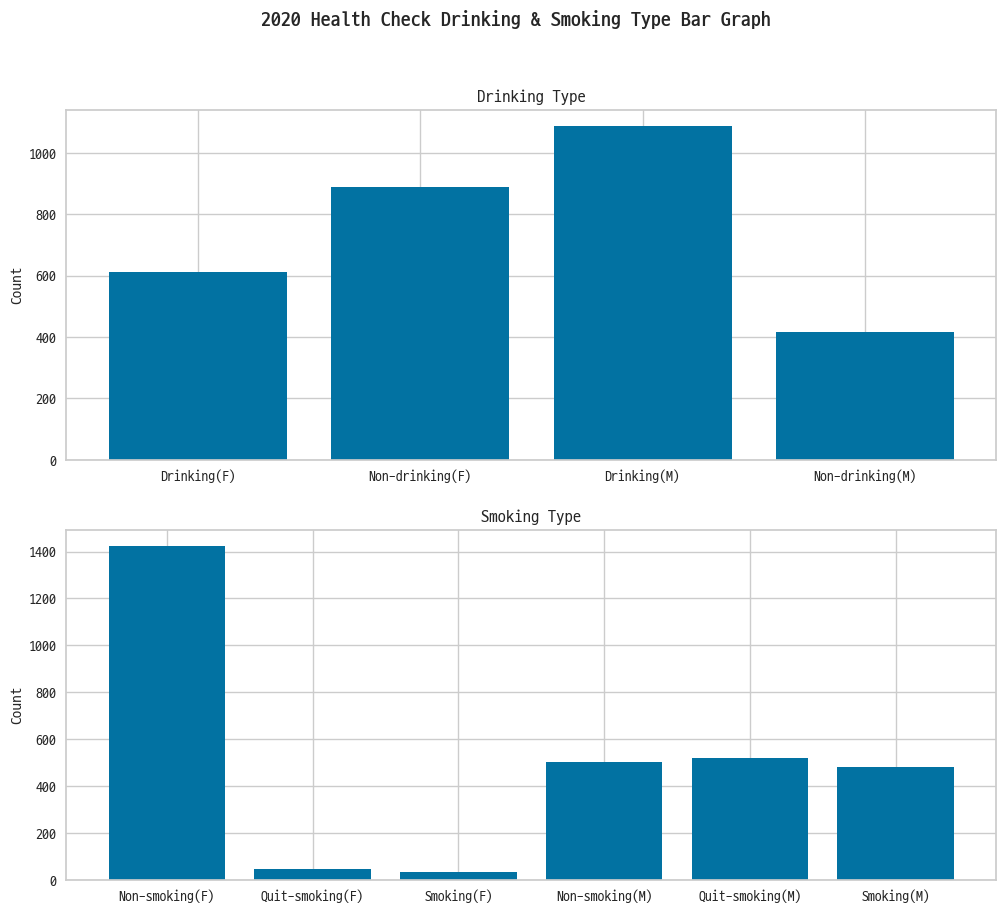

In [ ]:
fig = plt.figure(figsize=(12,10))
fig.suptitle('2020 Health Check Drinking & Smoking Type Bar Graph',fontweight='bold')   
index1 = np.arange(4)
index2 = np.arange(6)

fig.add_subplot(2,1,1)  # 2행 1열 그림파일에 1행 영역

plt.bar(index1, drinking['count'])
plt.title('Drinking Type')
plt.ylabel('Count')
plt.xticks(index1, ['Drinking(F)','Non-drinking(F)','Drinking(M)','Non-drinking(M)',])

fig.add_subplot(2,1,2)

plt.bar(index2, smoking['count'])
plt.title('Smoking Type')
plt.ylabel('Count')
plt.xticks(index2, ['Non-smoking(F)','Quit-smoking(F)','Smoking(F)','Non-smoking(M)','Quit-smoking(M)','Smoking(M)'])

plt.show()

In [10]:
## data6 에서, 남성 데이터만 모으기
maledata = data6[data6['gender']=="M"]
maledata.head()

,gender,height,weight,waist,drinking,smoking
0,M,165,60,72.1,Non-drinking,Non-smoking
2,M,185,85,94.0,Drinking,Smoking
3,M,165,80,93.0,Drinking,Smoking
6,M,160,65,90.0,Drinking,Non-smoking
9,M,165,55,77.5,Non-drinking,Non-smoking


In [11]:
## data6 에서, 여성 데이터만 모으기
femaledata = data6[data6['gender']=="F"]
femaledata.head()

,gender,height,weight,waist,drinking,smoking
1,F,155,50,75.2,Non-drinking,Non-smoking
4,F,150,50,82.0,Non-drinking,Non-smoking
5,F,155,55,84.0,Non-drinking,Non-smoking
7,F,145,60,90.0,Non-drinking,Non-smoking
8,F,155,50,65.9,Non-drinking,Non-smoking


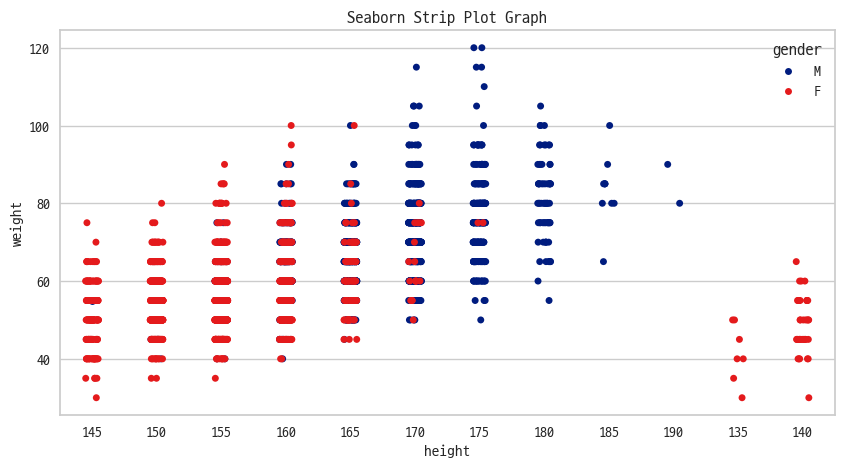

In [12]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(x='height', y='weight', data=maledata, hue='gender',palette='dark')
sns.stripplot(x='height', y='weight', data=femaledata, hue='gender',palette='Set1')
plt.show()

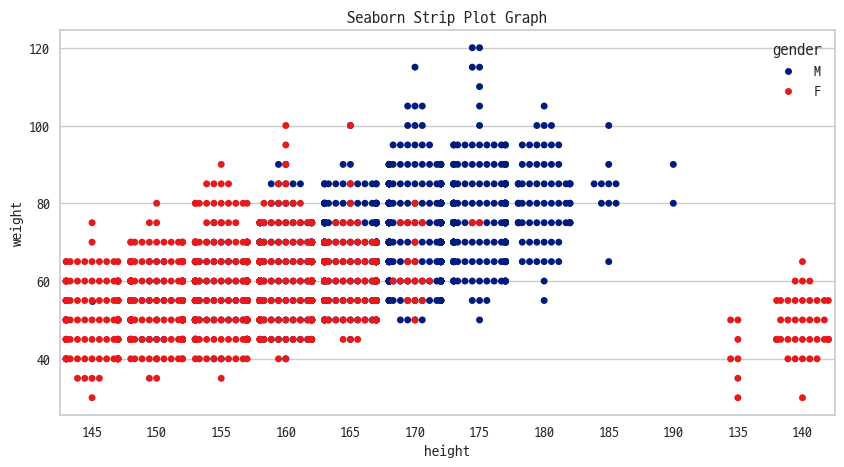

In [13]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.swarmplot(x='height', y='weight', data=maledata, hue='gender',palette='dark')
sns.swarmplot(x='height', y='weight', data=femaledata, hue='gender',palette='Set1')
plt.show()

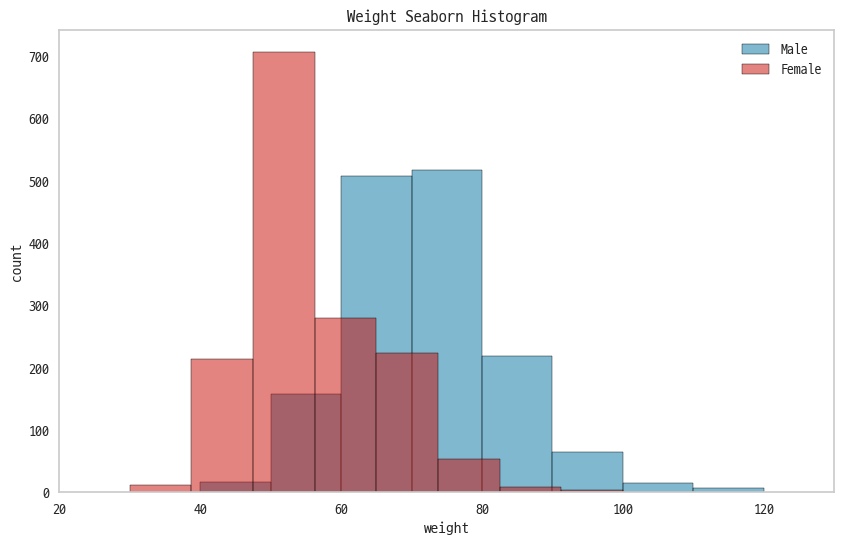

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(maledata['weight'],bins=8,alpha=0.5,label='Male')
sns.histplot(femaledata['weight'],bins=8,alpha=0.5,label='Female',color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()

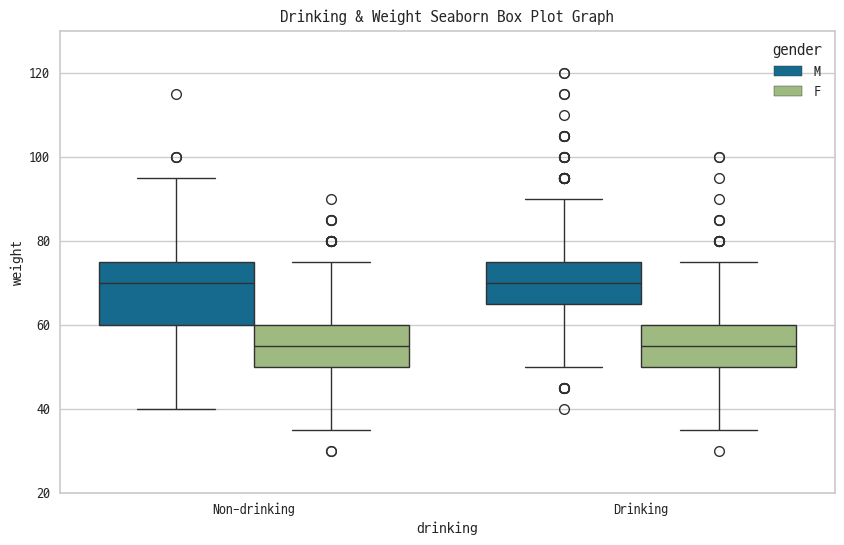

In [23]:
plt.figure(figsize=(10,6))
plt.title('Drinking & Weight Seaborn Box Plot Graph')

sns.boxplot(x='drinking',y='weight',hue='gender',data=data6)
plt.ylim(20,130)
plt.show()

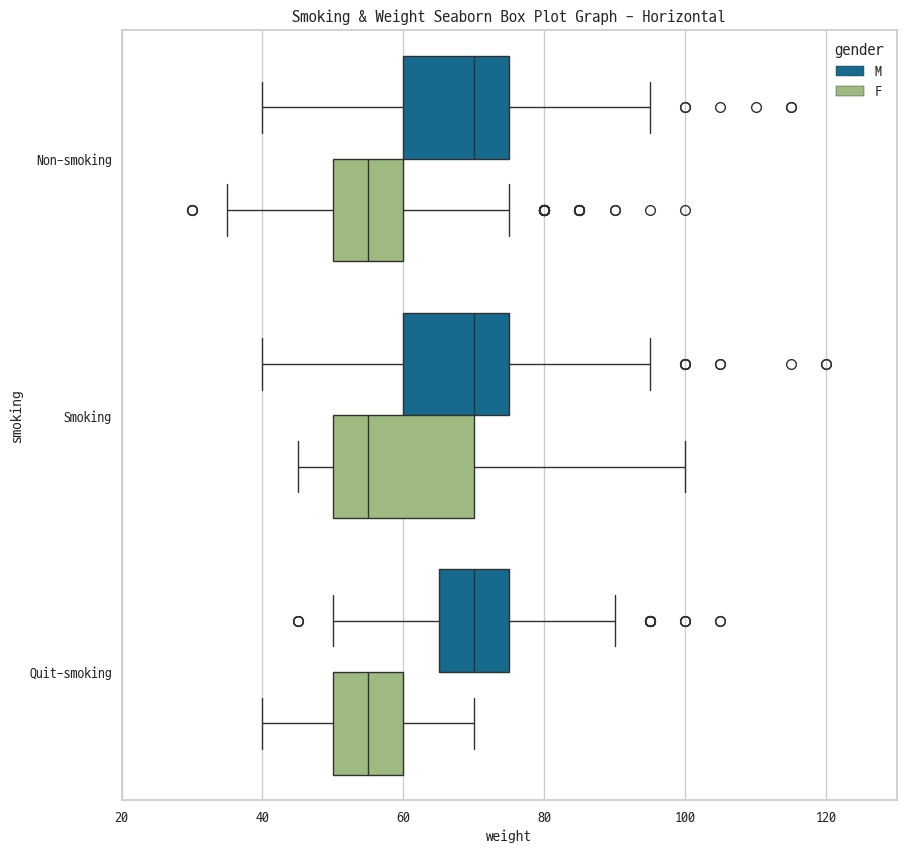

In [25]:
plt.figure(figsize=(10,10))
plt.title('Smoking & Weight Seaborn Box Plot Graph - Horizontal')

sns.boxplot(x='weight',y='smoking',hue='gender',data=data6,orient='h')
plt.xlim(20,130)
plt.show()

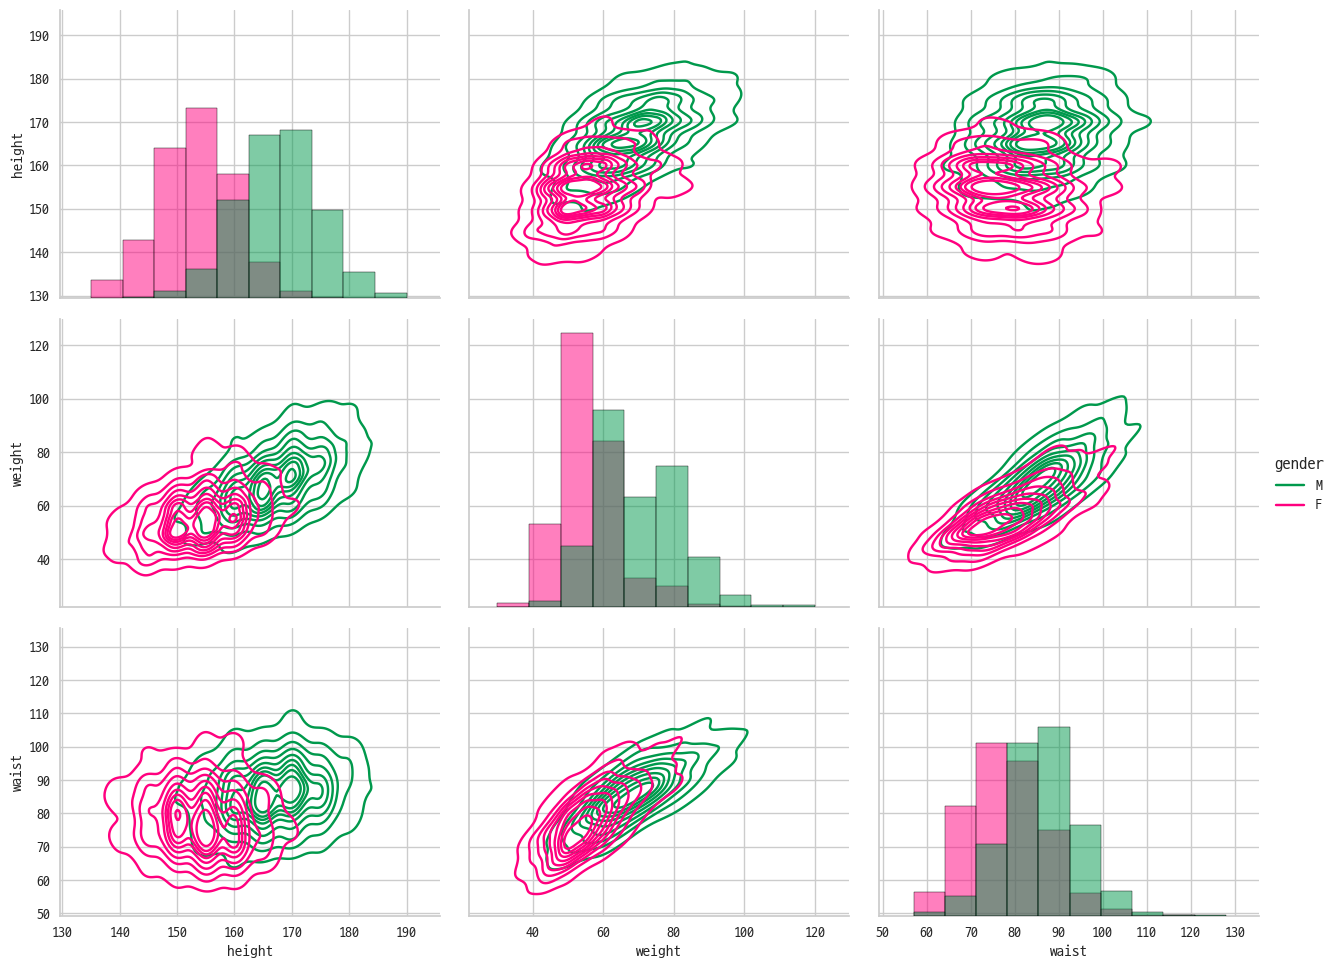

In [ ]:
color = ['#00994C', '#FF007F']
pp = sns.PairGrid(data6,hue='gender',palette=color,height=3.3,aspect=1.3)
pp.map_diag(sns.histplot,bins=10)   ## 대각선 방향에 히스토그램 그리기
pp.map_offdiag(sns.kdeplot)         ## 대각선 제외한 곳에 kde곡선(분포밀도를 부드러운 선으로)그리기
pp.add_legend()